## Downscaling NDVI and NDWI rasters to 30m 
To have same-level scale with LST images

In [1]:
!pip install rasterio
!pip install geopandas

  Using cached rasterio-1.4.3-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (22.2 MB)
  Using cached affine-2.4.0-py3-none-any.whl (15 kB)
  Using cached cligj-0.7.2-py3-none-any.whl (7.1 kB)
  Using cached click_plugins-1.1.1.2-py2.py3-none-any.whl (11 kB)
  Using cached geopandas-1.1.1-py3-none-any.whl (338 kB)
  Using cached pyogrio-0.11.1-cp310-cp310-manylinux_2_28_x86_64.whl (27.5 MB)
  Using cached pyproj-3.7.1-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (9.3 MB)
  Using cached shapely-2.1.2-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (3.1 MB)


In [2]:
import glob
import rasterio
from rasterio.warp import reproject, Resampling
import numpy as np
from tqdm import tqdm
import os

In [3]:
lst_path = '../2.LST/LC09_L2SP_192029_20240809_20240810_02_T1_ST_B10.tif' # here put the path of the LST image (target resolution)
ndvi_paths = glob.glob("temp_ndvi/*.tif") # here put the path of the NDVI folder
ndwi_paths = glob.glob("temp_ndwi/*.tif") # here put the path of the NDWI folder

In [4]:
with rasterio.open(lst_path) as src:
    product1 = src.read(1) * 0.00341802 - 124.15  # °C
    transform = src.transform
    crs = src.crs
    res = src.res  # pixel size (x and y)
    bounds = src.bounds  # total extension
    width, height = src.width, src.height

print("CRS:", crs)
print("Resolution (m):", res)
print("Extension:", bounds)
print("Dimensions:", width, "x", height)


CRS: EPSG:32632
Resolution (m): (30.0, 30.0)
Extension: BoundingBox(left=586485.0, bottom=4825485.0, right=816015.0, top=5058615.0)
Dimensions: 7651 x 7771


## Generate one NDVI mosaic

In [8]:
import rasterio
import numpy as np
from rasterio.transform import from_origin
import geopandas as gpd
from tqdm import tqdm
import glob
import os
from math import ceil

# --- Parameters ---
ndvi_paths = glob.glob("temp_ndvi/*.tif")
output_folder = "ndvi_mosaic_disk/"
os.makedirs(output_folder, exist_ok=True)
output_path = os.path.join(output_folder, "ndvi_mosaic.tif")
boundary_path = "../bologne_boundary.geojson"
batch_size = 50  # number of NDVI files per batch

# --- Step 1: get mosaic extent from boundary ---
boundary = gpd.read_file(boundary_path)
minx, miny, maxx, maxy = boundary.total_bounds

# --- Step 2: get resolution and nodata from first NDVI ---
with rasterio.open(ndvi_paths[0]) as src:
    res_x = src.transform.a
    res_y = -src.transform.e
    dtype = src.dtypes[0]
    nodata = src.nodata
    profile_base = src.profile.copy()

# --- Step 3: compute mosaic size and transform ---
width = ceil((maxx - minx) / res_x)
height = ceil((maxy - miny) / res_y)
transform = from_origin(minx, maxy, res_x, res_y)

# --- Step 4: create output mosaic on disk ---
profile_base.update({
    'height': height,
    'width': width,
    'transform': transform,
    'dtype': 'float32',
    'count': 1,
    'compress': 'lzw',
    'nodata': np.nan
})

# --- Split NDVI files into batches ---
ndvi_batches = [ndvi_paths[i:i + batch_size] for i in range(0, len(ndvi_paths), batch_size)]

with rasterio.open(output_path, "w+", **profile_base) as dst:
    for batch_idx, batch in enumerate(ndvi_batches, 1):
        print(f"Processing batch {batch_idx}/{len(ndvi_batches)}...")
        for ndvi_file in tqdm(batch, desc=f"Batch {batch_idx}"):
            with rasterio.open(ndvi_file) as src:
                data = src.read(1).astype(np.float32)
                rows, cols = data.shape

                # compute offsets relative to mosaic origin
                col_off = int(round((src.bounds.left - minx) / res_x))
                row_off = int(round((maxy - src.bounds.top) / res_y))

                # clip window to mosaic bounds
                win_col_start = max(col_off, 0)
                win_row_start = max(row_off, 0)
                win_col_end = min(col_off + cols, width)
                win_row_end = min(row_off + rows, height)

                # skip tiles completely outside mosaic
                if win_col_start >= win_col_end or win_row_start >= win_row_end:
                    continue

                # corresponding slice of NDVI tile
                data_row_start = max(0, 0 - row_off)
                data_col_start = max(0, 0 - col_off)
                data_row_end = data_row_start + (win_row_end - win_row_start)
                data_col_end = data_col_start + (win_col_end - win_col_start)
                data_slice = (slice(data_row_start, data_row_end), slice(data_col_start, data_col_end))

                # read mosaic block
                mosaic_block = dst.read(1, window=rasterio.windows.Window(
                    win_col_start, win_row_start,
                    win_col_end - win_col_start, win_row_end - win_row_start),
                    boundless=True, fill_value=np.nan
                )

                # fill only where mosaic is nodata
                tile_block = data[data_slice]
                fill_mask = np.isnan(mosaic_block) & (~np.isnan(tile_block))
                mosaic_block[fill_mask] = tile_block[fill_mask]

                # write back updated block
                dst.write(mosaic_block, 1, window=rasterio.windows.Window(
                    win_col_start, win_row_start,
                    win_col_end - win_col_start, win_row_end - win_row_start)
                )

print(f"Disk-based NDVI mosaic saved at {output_path}")


Processing batch 1/4...


Batch 1: 100%|██████████| 50/50 [00:56<00:00,  1.12s/it]


Processing batch 2/4...


Batch 2: 100%|██████████| 50/50 [01:07<00:00,  1.34s/it]


Processing batch 3/4...


Batch 3: 100%|██████████| 50/50 [01:10<00:00,  1.41s/it]


Processing batch 4/4...


Batch 4: 100%|██████████| 49/49 [01:07<00:00,  1.37s/it]

Disk-based NDVI mosaic saved at ndvi_mosaic_disk/ndvi_mosaic.tif


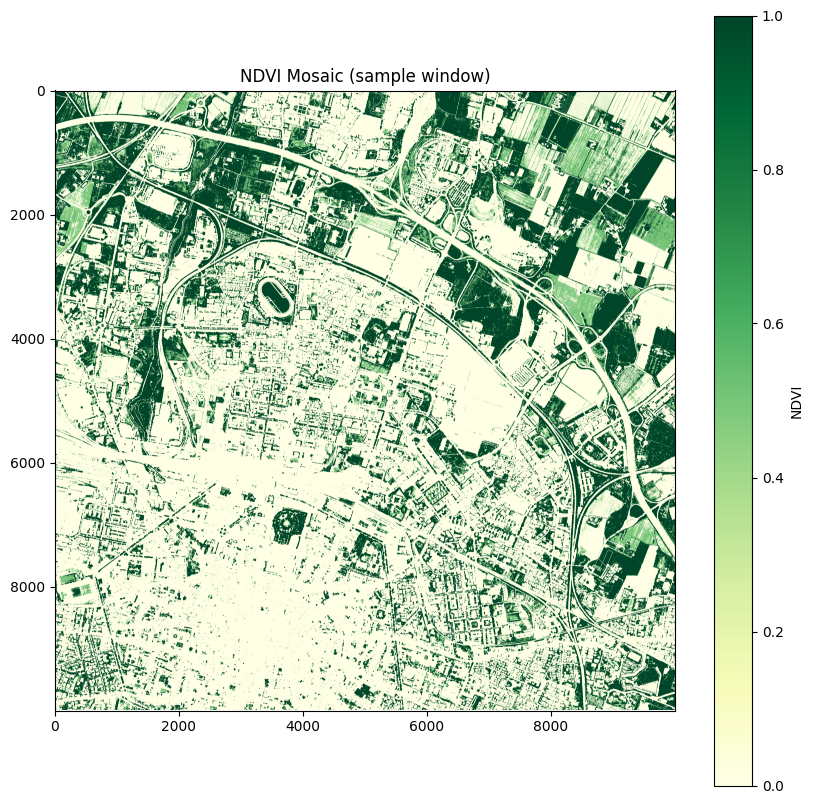

In [4]:
#print a window
import rasterio
import matplotlib.pyplot as plt

# --- Parameters ---
mosaic_path = "ndvi_mosaic_disk/ndvi_mosaic.tif"

# --- Open mosaic ---
with rasterio.open(mosaic_path) as src:
    # define a small window (row_start, row_stop, col_start, col_stop)
    window = rasterio.windows.Window(col_off=15000, row_off=5000, width=10000, height=10000)  # adjust as needed
    data = src.read(1, window=window)

    # get transform for plotting
    transform = src.window_transform(window)

# --- Plot ---
fig, ax = plt.subplots(figsize=(10,10))
img = ax.imshow(data, cmap='YlGn', vmin=0, vmax=1)
ax.set_title("NDVI Mosaic (sample window)")
plt.colorbar(img, ax=ax, label="NDVI")
plt.show()


## process the mosaic to generate a single 30 m resolution raster per class (0, 0.5, 1) aligned with a reference LST raster:

1. Converts the class of interest into a binary mask (1 if pixel belongs to the class, 0 otherwise).  
2. Resamples and aggregates the binary mask to the 30 m LST grid using the average, effectively computing the proportion of pixels of that class within each 30 m pixel. 

In [ ]:
'''
import rasterio
import numpy as np
from rasterio.warp import reproject, Resampling
import os
from tqdm import tqdm

# --- Parámetros ---
mosaic_path = "ndvi_mosaic_disk/ndvi_mosaic.tif"  # mosaico NDVI
classes = [0, 0.5, 1]                            # clases NDVI
output_folder = "ndvi_pct_30m/"                  # carpeta de salida

# --- Abrir LST como referencia espacial ---
with rasterio.open(lst_path) as src_lst:
    lst_profile = src_lst.profile
    lst_transform = src_lst.transform
    lst_crs = src_lst.crs
    lst_shape = (src_lst.height, src_lst.width)

# --- Inicializar acumuladores por clase ---
accumulators = {val: np.zeros(lst_shape, dtype=np.float32) for val in classes}
os.makedirs(output_folder, exist_ok=True)

# --- Leer NDVI mosaico ---
with rasterio.open(mosaic_path) as src_ndvi:
    ndvi_data = src_ndvi.read(1).astype(float)
    ndvi_transform = src_ndvi.transform
    ndvi_crs = src_ndvi.crs

# --- Procesar clases ---
for val in tqdm(classes, desc="Reproyectando clases NDVI"):
    mask_class = (ndvi_data == val).astype(float)
    resampled = np.empty(lst_shape, dtype=np.float32)

    reproject(
        source=mask_class,
        destination=resampled,
        src_transform=ndvi_transform,
        src_crs=ndvi_crs,
        dst_transform=lst_transform,
        dst_crs=lst_crs,
        resampling=Resampling.average
    )

    accumulators[val] += resampled  # en este caso, es solo un mosaico

# --- Guardar resultados ---
for val in classes:
    out_profile = lst_profile.copy()
    out_profile.update(dtype=rasterio.float32, count=1, compress='lzw')
    out_path = f"{output_folder}ndvi_class{str(val).replace('.', 'p')}_total_30m.tif"

    with rasterio.open(out_path, "w", **out_profile) as dst:
        dst.write(accumulators[val], 1)

    print(f"Clase {val} guardada en {out_path}")
'''
# Muy pesado

In [ ]:
import rasterio
import numpy as np
from rasterio.warp import reproject, Resampling, calculate_default_transform
from rasterio.windows import Window
import os
from tqdm import tqdm

# --- Parámetros ---
mosaic_path = "ndvi_mosaic_disk/ndvi_mosaic.tif"  # mosaico NDVI
classes = [0, 0.5, 1]                            # clases NDVI
output_folder = "ndvi_pct_30m/"
block_size = 1024                                # tamaño del bloque NDVI

os.makedirs(output_folder, exist_ok=True)

# --- Abrir LST (referencia espacial) ---
with rasterio.open(lst_path) as src_lst:
    lst_profile = src_lst.profile
    lst_transform = src_lst.transform
    lst_crs = src_lst.crs
    lst_shape = (src_lst.height, src_lst.width)

# --- Crear archivos de salida vacíos (uno por clase) ---
out_paths = {}
for val in classes:
    out_path = f"{output_folder}ndvi_class{str(val).replace('.', 'p')}_total_30m.tif"
    out_paths[val] = out_path
    out_profile = lst_profile.copy()
    out_profile.update(dtype=rasterio.float32, count=1, compress='lzw')
    with rasterio.open(out_path, "w", **out_profile) as dst:
        dst.write(np.zeros(lst_shape, dtype=np.float32), 1)

# --- Procesar mosaico NDVI por bloques ---
with rasterio.open(mosaic_path) as src_ndvi:
    ndvi_crs = src_ndvi.crs
    ndvi_transform = src_ndvi.transform
    width, height = src_ndvi.width, src_ndvi.height

    for row_start in tqdm(range(0, height, block_size), desc="Procesando NDVI por bloques"):
        for col_start in range(0, width, block_size):
            win = Window(col_start, row_start,
                         min(block_size, width - col_start),
                         min(block_size, height - row_start))
            ndvi_block = src_ndvi.read(1, window=win).astype(float)
            block_transform = src_ndvi.window_transform(win)

            for val in classes:
                mask_class = (ndvi_block == val).astype(float)

                # calcular transform y shape del bloque reproyectado
                dst_transform, dst_width, dst_height = calculate_default_transform(
                    ndvi_crs, lst_crs,
                    mask_class.shape[1], mask_class.shape[0],
                    *rasterio.windows.bounds(win, ndvi_transform),
                    dst_width=lst_shape[1], dst_height=lst_shape[0],
                )

                # inicializar array más pequeño para reprojectar solo lo necesario
                resampled_block = np.zeros((dst_height, dst_width), dtype=np.float32)

                reproject(
                    source=mask_class,
                    destination=resampled_block,
                    src_transform=block_transform,
                    src_crs=ndvi_crs,
                    dst_transform=dst_transform,
                    dst_crs=lst_crs,
                    resampling=Resampling.average
                )

                # calcular ventana del LST donde escribir
                row_off = int(round((dst_transform.f - lst_transform.f) / lst_transform.e))
                col_off = int(round((dst_transform.c - lst_transform.c) / lst_transform.a))
                row_off = max(row_off, 0)
                col_off = max(col_off, 0)

                win_out = Window(col_off, row_off,
                                 min(resampled_block.shape[1], lst_shape[1] - col_off),
                                 min(resampled_block.shape[0], lst_shape[0] - row_off))

                # escribir solo esa ventana
                with rasterio.open(out_paths[val], "r+") as dst:
                    dst_data = dst.read(1, window=win_out)
                    dst_data += resampled_block[:win_out.height, :win_out.width]
                    dst.write(dst_data, 1, window=win_out)

print("✅ Reproyección y escritura completadas sin solapamientos ni franjas vacías.")


Procesando NDVI por bloques:   7%|▋         | 2/30 [15:36<3:40:21, 472.18s/it]